# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [2]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Litza Fernanda Ladrilleros Torres"            # Tu nombre completo
MATRICULA = "81558"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Litza Fernanda Ladrilleros Torres
Matrícula: 81558
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [1]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\ferto\Documents\Escuela\5semestre\Topicos de Big Data\BigData\examen1parcial\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [ ]:
df.head(25)

## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [5]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [6]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [7]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [8]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

que haya nulos no impide que se pueda hacer el analisis de los datos

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [35]:
# ¿Cuántos países distintos hay? Para el año más reciente disponible (2020), muestra los 10 países con mayor porcentaje de consumo y los 10 con menor porcentaje.
# Codigo
df_paises = df[df[config["filtro_paises"]].notna()].copy()
n_paises = df_paises['entity'].nunique()
print(n_paises)

df_2020 = df_paises[df_paises['year'] == 2020]
top10 = df_2020.sort_values('valor', ascending=False).head(10)
bottom10 = df_2020.sort_values('valor', ascending=True).head(10)
print(top10[['entity', 'valor']])
print(bottom10[['entity', 'valor']])


189
           entity      valor
2120   Luxembourg  84.195100
1742      Ireland  83.209274
83        Andorra  82.505775
188     Australia  80.670130
2541  New Zealand  80.278630
3424  Switzerland  79.957200
209       Austria  79.401760
1637      Iceland  79.204660
1406      Germany  78.830920
1007      Denmark  78.287570
            entity     valor
1931        Kuwait  0.830784
3256       Somalia  0.922955
797        Comoros  0.952743
3886         Yemen  1.152923
2078         Libya  1.258470
3445         Syria  1.496604
1700          Iran  1.545203
2730      Pakistan  1.574980
2267    Mauritania  1.743128
3087  Saudi Arabia  1.869912


**Interpretación:**

Con este filtra se comprueba que los países que mas consumen alcohol son  la mayoria europeos, mientras que los que menos consumen son países musulmanes; lo que refleja la diferencia que hay entre las culturas

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [18]:
# Elige 4 países de tu interés y filtra el DataFrame para mostrar únicamente su información entre 2010 y 2020
# Codigo
paises_interes = ['Luxembourg', 'Ireland', 'Mexico', 'Australia']
filtro = df_paises['entity'].isin(paises_interes) & (df_paises['year'] >= 2010) & (df_paises['year'] <= 2020)
df_subset = df_paises[filtro]
print(df_subset[['entity', 'year', 'valor']].sort_values(['entity', 'year']))

          entity  year      valor
178    Australia  2010  80.811360
179    Australia  2011  80.802170
180    Australia  2012  80.617966
181    Australia  2013  80.750084
182    Australia  2014  80.688040
183    Australia  2015  80.432556
184    Australia  2016  80.528030
185    Australia  2017  80.335785
186    Australia  2018  80.416590
187    Australia  2019  80.472020
188    Australia  2020  80.670130
1732     Ireland  2010  81.892700
1733     Ireland  2011  81.898300
1734     Ireland  2012  81.824790
1735     Ireland  2013  81.267780
1736     Ireland  2014  81.654600
1737     Ireland  2015  82.723440
1738     Ireland  2016  83.073006
1739     Ireland  2017  83.240135
1740     Ireland  2018  83.509960
1741     Ireland  2019  83.445206
1742     Ireland  2020  83.209274
2110  Luxembourg  2010  83.859245
2111  Luxembourg  2011  84.092380
2112  Luxembourg  2012  84.121300
2113  Luxembourg  2013  84.155235
2114  Luxembourg  2014  84.348720
2115  Luxembourg  2015  84.350390
2116  Luxembou

**Interpretación:**

Los paises como Australia, Irlanda y Luxemburgo tienen un consumo alto y continuo durante los años 2010-2020, mientras se ve que México no tiene tanto consumo, de hecho hasta baja.

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [20]:
# Compara el porcentaje de consumo de alcohol entre 5 países que tú elijas (de distintos continentes) en el año 2019. ¿Cuál tiene el valor más alto y cuál el más bajo? ¿Qué diferencia porcentual hay entre ellos?
# codigo
paises_5 = ['Luxembourg', 'Australia', 'Somalia', 'Japan', 'Mexico']
df_2019 = df_paises[(df_paises['entity'].isin(paises_5)) & (df_paises['year'] == 2019)]
print(df_2019[['entity', 'valor']].sort_values('valor', ascending=False))

max_val = df_2019['valor'].max()
min_val = df_2019['valor'].min()
pais_max = df_2019.loc[df_2019['valor'].idxmax(), 'entity']
pais_min = df_2019.loc[df_2019['valor'].idxmin(), 'entity']
print(pais_max, max_val, pais_min, min_val, max_val - min_val)

          entity      valor
2119  Luxembourg  84.505740
187    Australia  80.472020
1825       Japan  67.867800
2308      Mexico  43.971450
3255     Somalia   0.921953
Luxembourg 84.50574 Somalia 0.9219528 83.5837872


**Interpretación:**

Luxemburgo y Somalia tienen una gran brecha de consumo, que que mientras Luxemburgo llega a ser el que mas consume de las entidades, Somalia es el que menos consume, con un valor del 0.921

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [23]:
# Define dos grupos de países con una lista propia (por ejemplo, "Europa" vs "Latinoamérica", usando 5 países representativos de cada uno)
# Codigo
europa = ['Germany', 'France', 'Spain', 'Italy', 'Luxembourg']
latam = ['Mexico', 'Colombia', 'Argentina', 'Peru', 'Chile']
anio_reciente = df_paises['year'].max()

prom_europa = df_paises[(df_paises['entity'].isin(europa)) & (df_paises['year'] == anio_reciente)]['valor'].mean()
prom_latam = df_paises[(df_paises['entity'].isin(latam)) & (df_paises['year'] == anio_reciente)]['valor'].mean()
print(prom_europa, prom_latam)


77.75976 58.101197400000004


**Interpretación:**
Los paises de europa llegan a comsumir un mayor porcentaje de alcohol que latinoamérica, teniendo casi 20 puntos de diferencia, reforzando la idea de que los paises de europa consumen más alcohol

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [24]:
# Para un país de tu elección, grafica (o calcula) cómo cambió el porcentaje de consumo de alcohol entre 2000 y 2020. ¿Aumentó o disminuyó? ¿En qué año tuvo su valor máximo y en cuál el mínimo? 
# Codigo 
pais_elegido = 'Mexico'
df_pais = df_paises[df_paises['entity'] == pais_elegido].sort_values('year')
print(df_pais[['year', 'valor']])

anio_max = df_pais.loc[df_pais['valor'].idxmax(), 'year']
anio_min = df_pais.loc[df_pais['valor'].idxmin(), 'year']
print(anio_max, anio_min)


      year      valor
2289  2000  43.696823
2290  2001  43.486710
2291  2002  43.310062
2292  2003  43.456112
2293  2004  43.573890
2294  2005  43.666603
2295  2006  44.073420
2296  2007  42.525486
2297  2008  42.630943
2298  2009  42.772570
2299  2010  42.275200
2300  2011  42.341488
2301  2012  42.171944
2302  2013  41.940746
2303  2014  42.286865
2304  2015  42.922820
2305  2016  43.080498
2306  2017  43.575916
2307  2018  43.875687
2308  2019  43.971450
2309  2020  42.036960
2006 2013


**Interpretación:**

México llega a consistente con el consumo que tiene entre los años 2000-2020, aunque ha llegado a bajar levemente el consumo en el año 2020

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [25]:
# 6. Calcula el cambio porcentual entre el primer y el último año disponible para los 5 países del punto 3. ¿Cuál tuvo el mayor incremento y cuál la mayor caída?
# codigo
resultados = []
for pais in paises_5:
    df_p = df_paises[df_paises['entity'] == pais].sort_values('year')
    primero = df_p.iloc[0]
    ultimo = df_p.iloc[-1]
    cambio_pct = ((ultimo['valor'] - primero['valor']) / primero['valor']) * 100
    resultados.append({'pais': pais, 'cambio_pct': cambio_pct})

df_cambios = pd.DataFrame(resultados)
print(df_cambios)
print(df_cambios.loc[df_cambios['cambio_pct'].idxmax(), 'pais'])
print(df_cambios.loc[df_cambios['cambio_pct'].idxmin(), 'pais'])

         pais  cambio_pct
0  Luxembourg    1.399356
1   Australia    0.882442
2     Somalia    1.134427
3       Japan   -4.670667
4      Mexico   -3.798590
Luxembourg
Japan


**Interpretación:**

Luxemburgo y Somalia tuvieron los mayores incrementos, mientras que Japón y México tuvieron las mayores caídas, dando a entender que tienen mas estabilidad en los extremos y más variación en los niveles intermedios

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [26]:
# Usando NumPy, calcula la media, mediana y desviación estándar del porcentaje de consumo de alcohol a nivel mundial (todos los países) para el año más reciente.
# Codigo
valores_2020 = df_2020['valor'].dropna().values
media = np.mean(valores_2020)
mediana = np.median(valores_2020)
desv_std = np.std(valores_2020)
print(media, mediana, desv_std)


42.25048457647059 42.03696 23.997187046049685


**Interpretación:**

La media (42.25%) y mediana (42.04%) tienen poco esgo, pero la desviación estándar alta (24.00) muestra gran variabilidad entre países debido a factores culturales y religiosos


### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

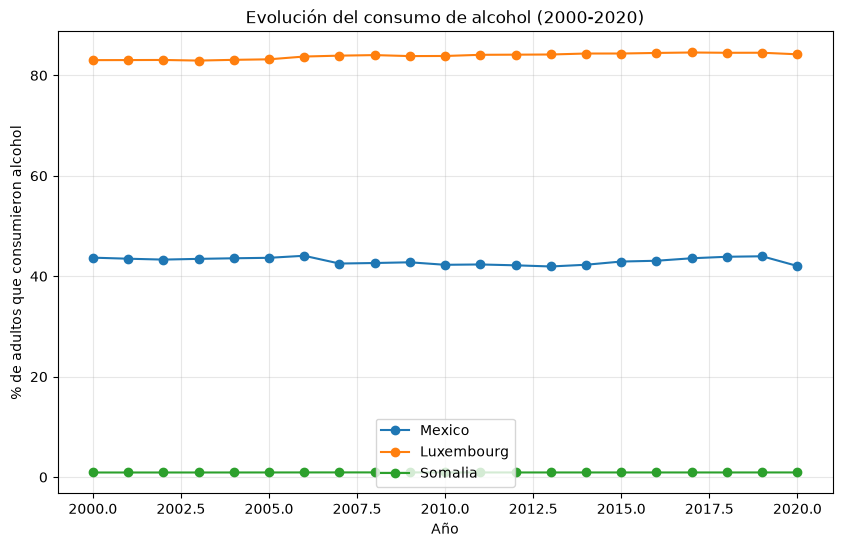

In [28]:
# Crea una gráfica de líneas con matplotlib que muestre la evolución del consumo de alcohol (2000–2020) para 3 países de tu elección en una sola figura, con leyenda y etiquetas de ejes. 
# Codigo
paises_grafica = ['Mexico', 'Luxembourg', 'Somalia']
plt.figure(figsize=(10, 6))
for pais in paises_grafica:
    df_p = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(df_p['year'], df_p['valor'], marker='o', label=pais)
plt.title('Evolución del consumo de alcohol (2000-2020)')
plt.xlabel('Año')
plt.ylabel('% de adultos que consumieron alcohol')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Interpretación:**

Se ve que hay una gran brecha entre los tres países, siendo que Luxemburgo se mantiene siempre por encima del 80%, México tiende a estar levemente encima del 40% y Somalia esta muy levemente por encima del 0%. Ninguno de los paises muestra algun gran cambio. todos siguen con su patron

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

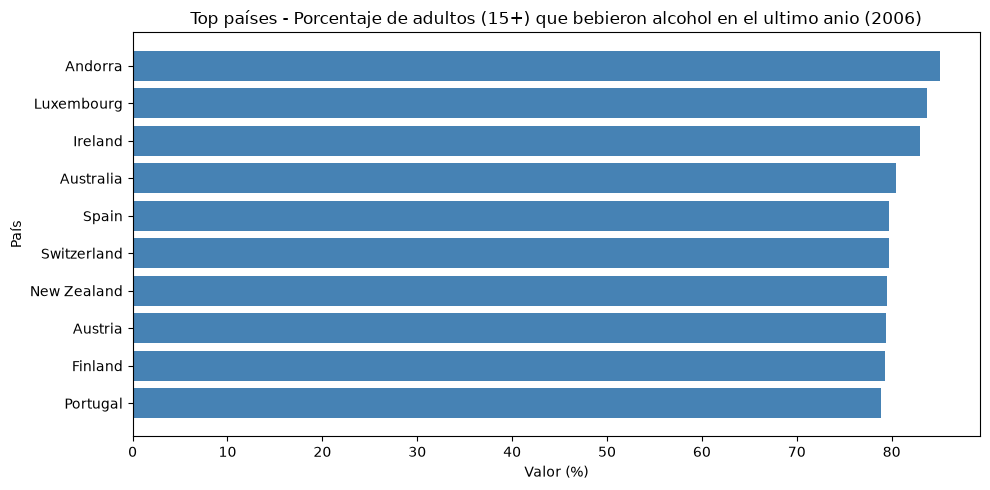

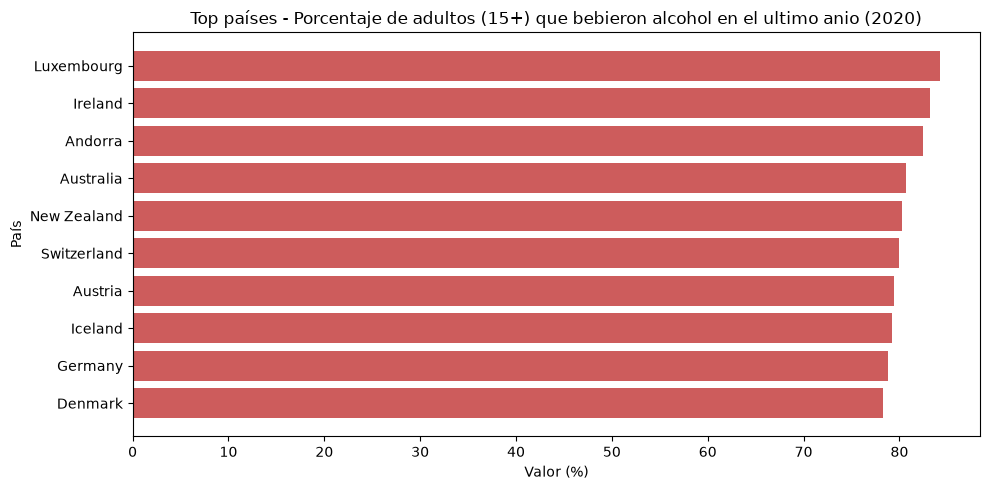

In [39]:
# Crea dos gráficas de barras horizontales con el Top 10 de países con mayor consumo de alcohol, la primera en el año de tu nacimiento, la segunda en el año 2023
# Codigo
df_paises = df[df[config["filtro_paises"]].notnull()]

año_consultado = 2006

top = (
    df_paises[df_paises['year'] == año_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({año_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


año_consultado2 = 2020

top2 = (
    df_paises[df_paises['year'] == año_consultado2]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top2['entity'], top2['valor'], color='indianred')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({año_consultado2})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:**

El ranking del top 10 es casi igual en ambos años 2006 y 2020, donde la mayoria de paises europeos son los que dominan en ambas tablas, aunque hay pequeños cambios de posición, esto refuerza que los países con mayor consumo de alcohol son europeos

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Con este dataset del consumo de alcohol, me di cuenta que este tiene que ver mas con la cultura y religión de cada regiónñ ya que los países con más consumo son europeos y los de menos son de mayoría musulmana, en los cuales donde el alcohol está mal visto o prohibido. y aparte algo que me llamó la atención es que comparando las tablas 2006-2020 casi no cambia el top 10, o sea que estos hábitos tardan mucho en modificarse.

De laas limitaciones que encontre, fue que el dataset solo llega hasta 2020 y nada más mide si la persona bebió alguna vez en el año, no que tanto tomo. Si tuviera más tiempo me hubiera gustado comparar esto con otras variables como PIB per cápita o salud para ver si realmente hay alguna relación, o meter más países por continente para que la comparación fuera más completa


## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
